# MATPLOTLIB

- simple graphs:

    - (line)plot
    - bar
    - histogram
    - pie
    - scatterplot

- superposing of graphs:

    - label
    - legend

- formatting

    - title
    - axis
    - (x/y)ticks
    - labels
    - color
    - markers
    - figure

- sub-graphs

    - subplot
    - subplots
    - suptitle
    - tight_layout

- intermediate graphs:

    - add data/column labels

- images and array plots

    - imshow

- seaborn library


In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


documentation:  
https://matplotlib.org/stable/gallery/index.html

exemples:  
https://matplotlib.org/stable/gallery/index.html

# Simple graphs

## lineplot

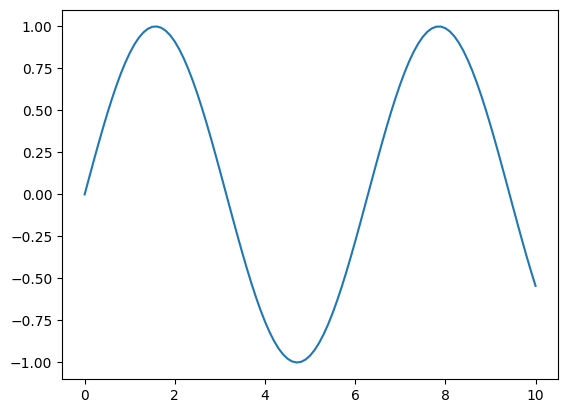

In [3]:
### create list of values in floats
x = np.linspace(0, 10, 101) # start (included), stop(included), number_of_values  

### plot= line-plot; plot(x,y,*args)

plt.plot(x, np.sin(x))


### show result of graphic
plt.show() 

# barplot

In [4]:
dict_map = {0:'a',1:'b',2:'c'}

df1 = pd.DataFrame(data = [{'num':np.random.normal(10+k,2+k,1)[0],
                            'cat':dict_map[k],
                            'cat2':dict_map[(k+1)%3],
                            'num2':np.random.randint(2*k,10+2*k,1)[0],
                           } for k in np.random.randint(0,3,size=(10_000))]
                  )
display(df1)

gb1 = df1.groupby('cat').mean(numeric_only=True).reset_index()
gb1

,num,cat,cat2,num2
0,8.472133,b,c,4
1,10.984953,b,c,5
2,12.690090,b,c,8
3,8.038628,b,c,9
4,15.160534,c,a,9
...,...,...,...,...
9995,11.436539,b,c,9
9996,12.517773,b,c,11
9997,9.740747,a,b,0
9998,16.883690,c,a,10


,cat,num,num2
0,a,10.039264,4.454130
1,b,11.053960,6.531351
2,c,11.975996,8.561409


In [5]:
df1['cat'].value_counts()

cat
b    3397
c    3322
a    3281
Name: count, dtype: int64

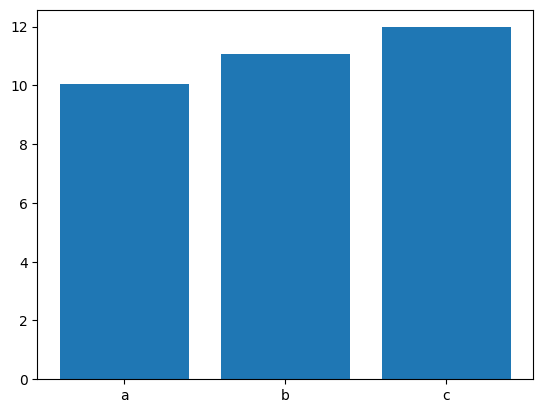

In [6]:
plt.bar(x=gb1['cat'],height= gb1['num'])
plt.show()

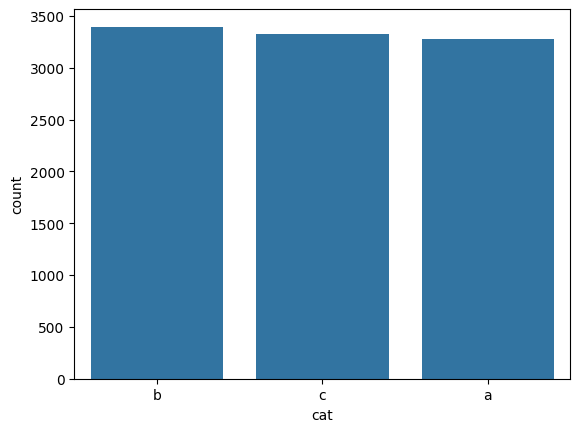

In [7]:
sns.countplot(data=df1,x='cat')
plt.show()

## histogram

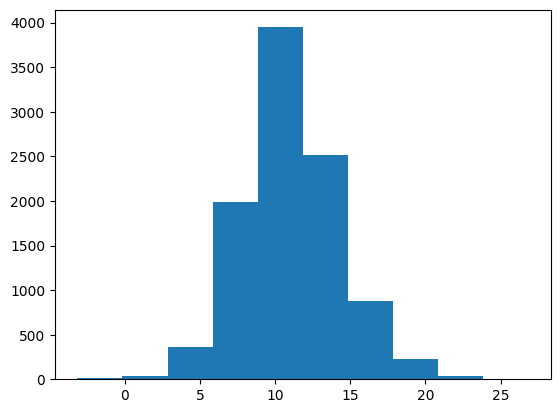

In [8]:
plt.hist(data = df1 , x='num')
plt.show()

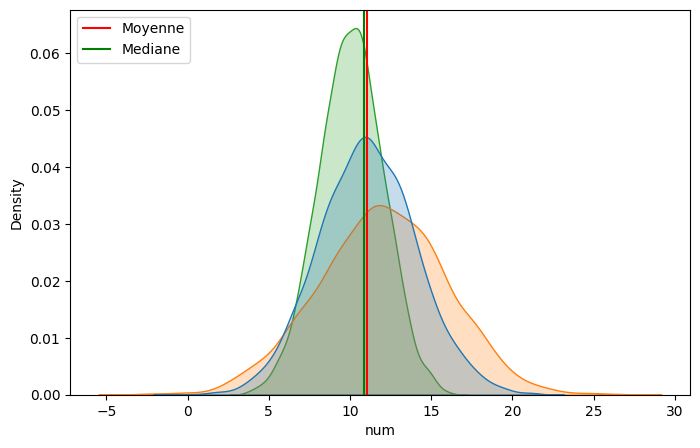

In [9]:
plt.figure(figsize=(8,5))


sns.kdeplot(data = df1 , x='num',hue='cat',fill=True)
plt.axvline(df1['num'].mean(),c='red',label='Moyenne')
plt.axvline(df1['num'].median(),c='green',label='Mediane')
plt.legend(loc=2)
plt.show()

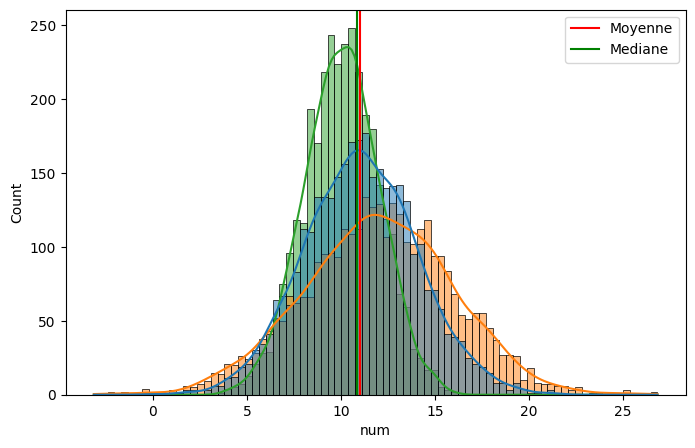

In [10]:
plt.figure(figsize=(8,5))


sns.histplot(data = df1 , x='num',hue='cat',fill=True,kde=True)
plt.axvline(df1['num'].mean(),c='red',label='Moyenne')
plt.axvline(df1['num'].median(),c='green',label='Mediane')
plt.legend()

plt.show()



## pie

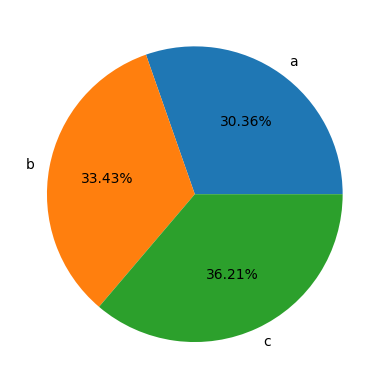

In [11]:
plt.pie(data=gb1, x='num', labels='cat', autopct='%1.2f%%')
plt.show()

## scatterplot

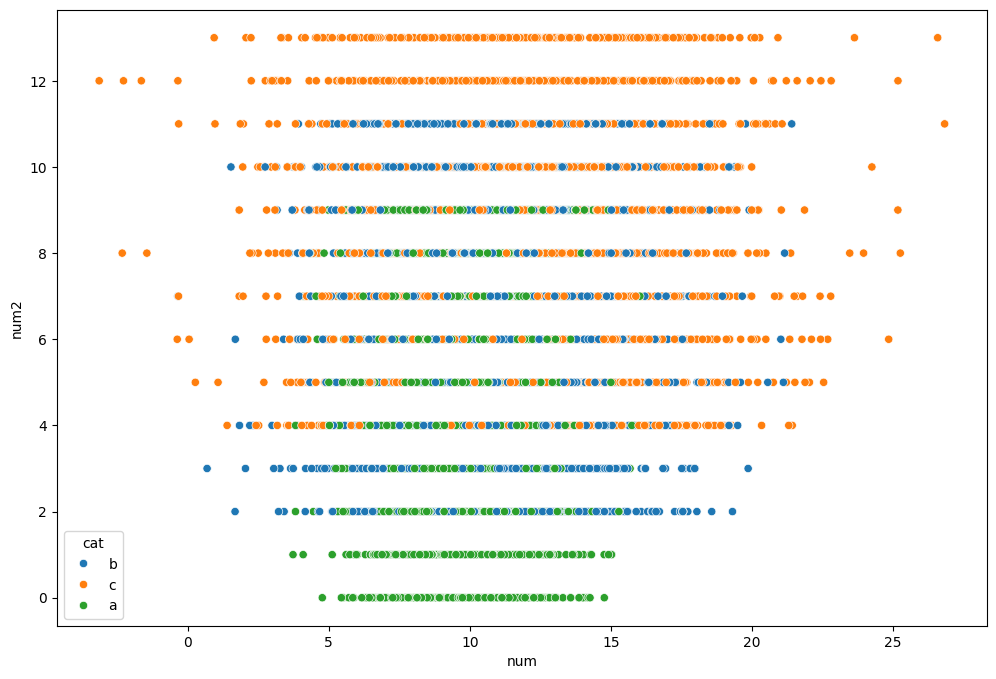

In [12]:
plt.figure(figsize=(12,8))
sns.scatterplot(data=df1, x='num',y='num2',hue='cat')
plt.show()

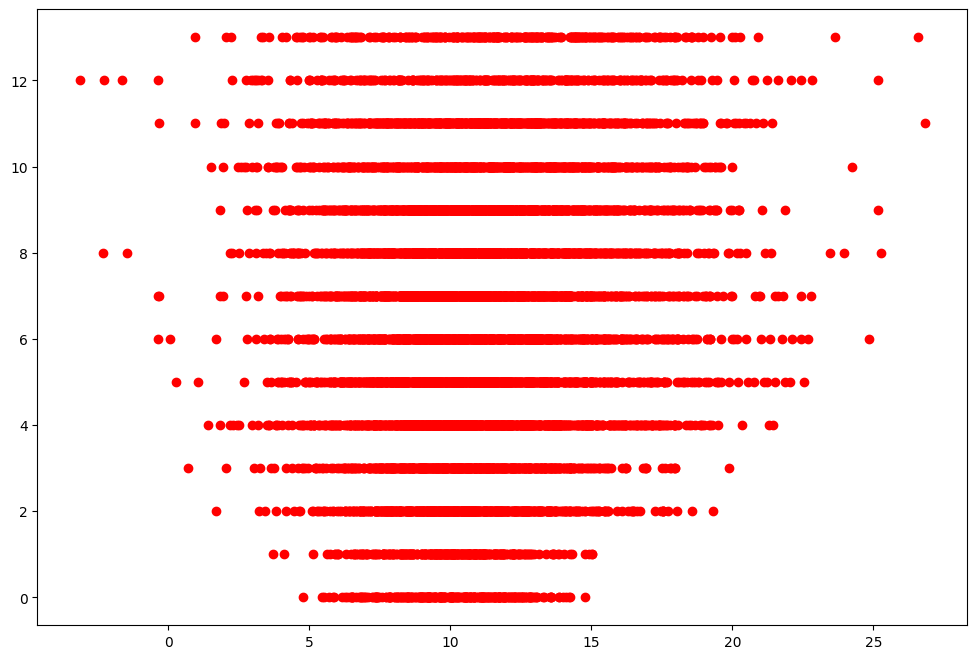

In [13]:
plt.figure(figsize=(12,8))
plt.scatter(data=df1, x='num',y='num2',c='red')
plt.show()

# Superposing

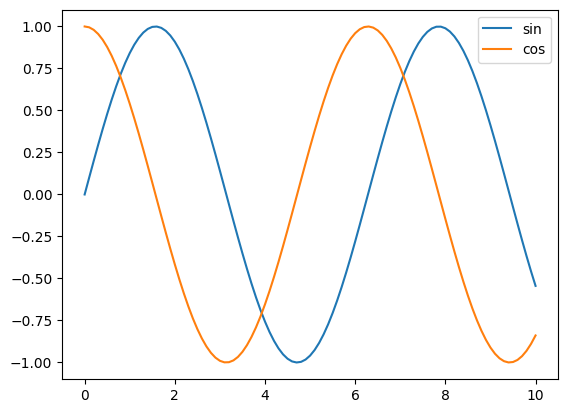

In [14]:
x = np.linspace(0, 10, 101) 


plt.plot(x, np.sin(x), label='sin') 
plt.plot(x, np.cos(x), label='cos') 

plt.legend()
plt.show()


In [15]:
gb2 = df1.groupby(['num2','cat']).std(numeric_only=True).reset_index()
gb2

,num2,cat,num
0,0,a,1.958580
1,1,a,1.919149
2,2,a,1.994547
3,2,b,2.949285
4,3,a,1.910584
5,3,b,3.077217
6,4,a,2.013680
7,4,b,3.043762
8,4,c,3.869112
9,5,a,1.997257


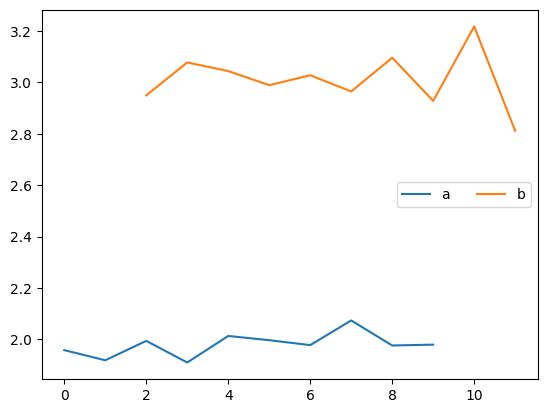

In [16]:
plt.plot('num2','num',data=gb2.loc[gb2['cat']=='a'], label ='a')
plt.plot('num2','num',data=gb2.loc[gb2['cat']=='b'], label ='b')
plt.legend(loc='center right', ncol=2)
plt.show()

# Formatting

In [17]:
x

array([ 0. ,  0.1,  0.2,  0.3,  0.4,  0.5,  0.6,  0.7,  0.8,  0.9,  1. ,
        1.1,  1.2,  1.3,  1.4,  1.5,  1.6,  1.7,  1.8,  1.9,  2. ,  2.1,
        2.2,  2.3,  2.4,  2.5,  2.6,  2.7,  2.8,  2.9,  3. ,  3.1,  3.2,
        3.3,  3.4,  3.5,  3.6,  3.7,  3.8,  3.9,  4. ,  4.1,  4.2,  4.3,
        4.4,  4.5,  4.6,  4.7,  4.8,  4.9,  5. ,  5.1,  5.2,  5.3,  5.4,
        5.5,  5.6,  5.7,  5.8,  5.9,  6. ,  6.1,  6.2,  6.3,  6.4,  6.5,
        6.6,  6.7,  6.8,  6.9,  7. ,  7.1,  7.2,  7.3,  7.4,  7.5,  7.6,
        7.7,  7.8,  7.9,  8. ,  8.1,  8.2,  8.3,  8.4,  8.5,  8.6,  8.7,
        8.8,  8.9,  9. ,  9.1,  9.2,  9.3,  9.4,  9.5,  9.6,  9.7,  9.8,
        9.9, 10. ])

In [18]:
def myfunct(x):
    
    y = np.exp(-0.5*(x-5)**2)
    
    return y

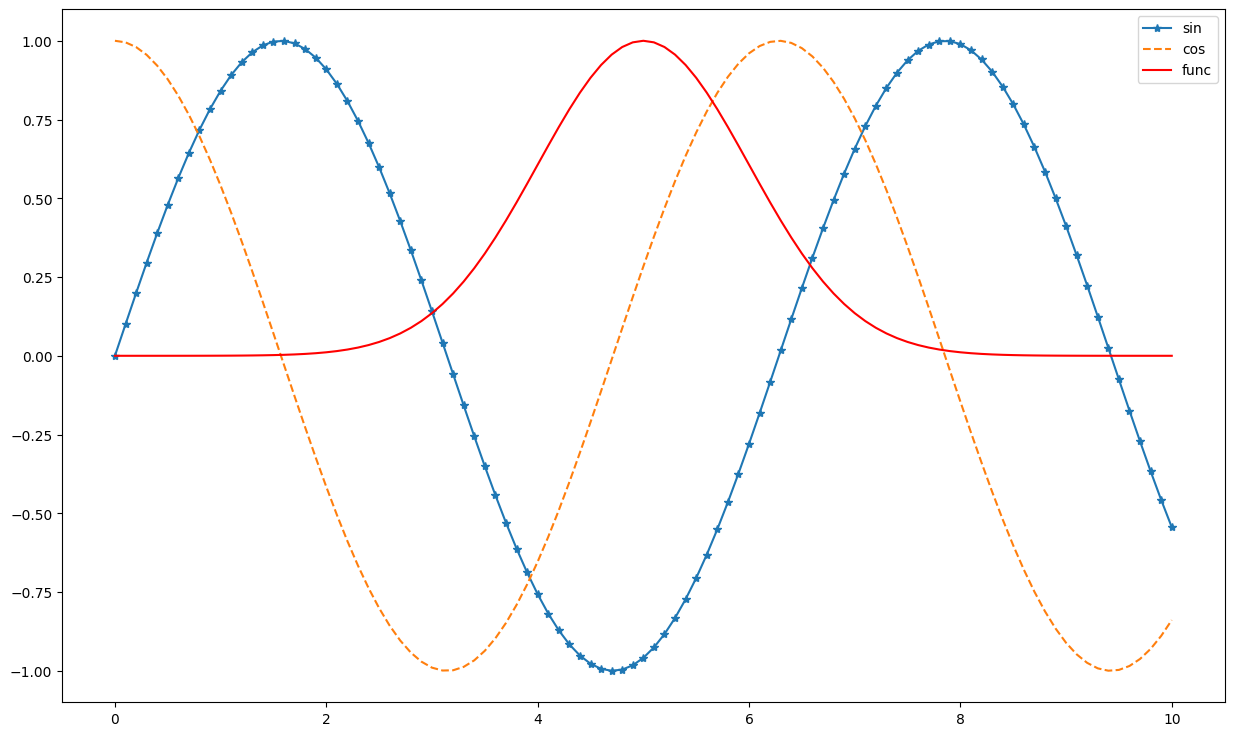

In [19]:
x = np.linspace(0, 10, 101) 
plt.figure(figsize=(15, 9)) # figsize = taille pouces

plt.plot(x, np.sin(x), linestyle = '-',label = "sin",marker='*')
plt.plot(x, np.cos(x), '--',label= 'cos')
plt.plot(x, myfunct(x), c='r',label = 'func')
plt.legend()

plt.savefig('demo.pdf') #png,...
plt.show() # toujours la dernière étape

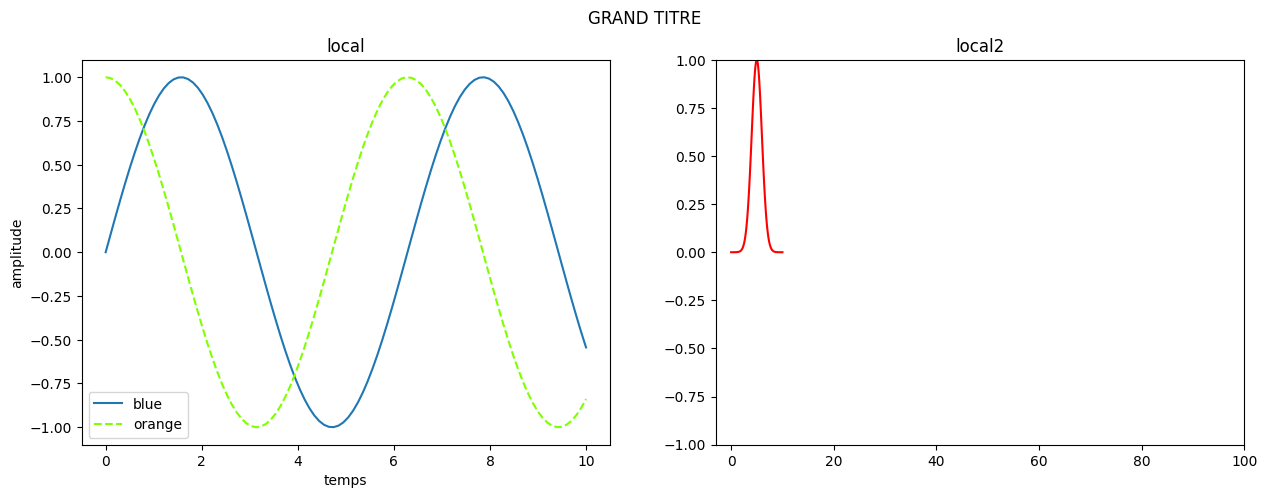

In [20]:
### alternative à la syntaxe suivante

x= np.linspace(0, 10, 100) # x = [i/10 for i in range(10*(10)+1)]


### taille 
plt.figure(figsize=(15, 5)) # taille en pouces

### super titre
plt.suptitle('GRAND TITRE')

### je construit un sous-graphique, 1 row, 2 cols, 1er graphique
### toutes les modif vont s'appliquer à ce sous-graph
plt.subplot(1,2,1) 
## titre sous-graphique
plt.title('local')
plt.plot(x, np.sin(x), linestyle = '-', label = 'blue') # label== nommer la couche -> legende
plt.plot(x, np.cos(x), '--', label = 'orange',c='chartreuse') ## pour la legende
### afficher legende
plt.legend() ## ce place automatiquement , le plus idéal

### nommer les axes
plt.xlabel('temps')
plt.ylabel('amplitude')


### definir le 2ième sous-graphique
plt.subplot(1,2,2)
plt.title('local2')
plt.plot(x, myfunct(x), c='r')

### modif des val min-max des axes
## [xmin, xmax,ymin, ymax]
plt.axis([-3,100,-1,1])

plt.savefig('testbx.jpg')
plt.show() # toujours la dernière étape

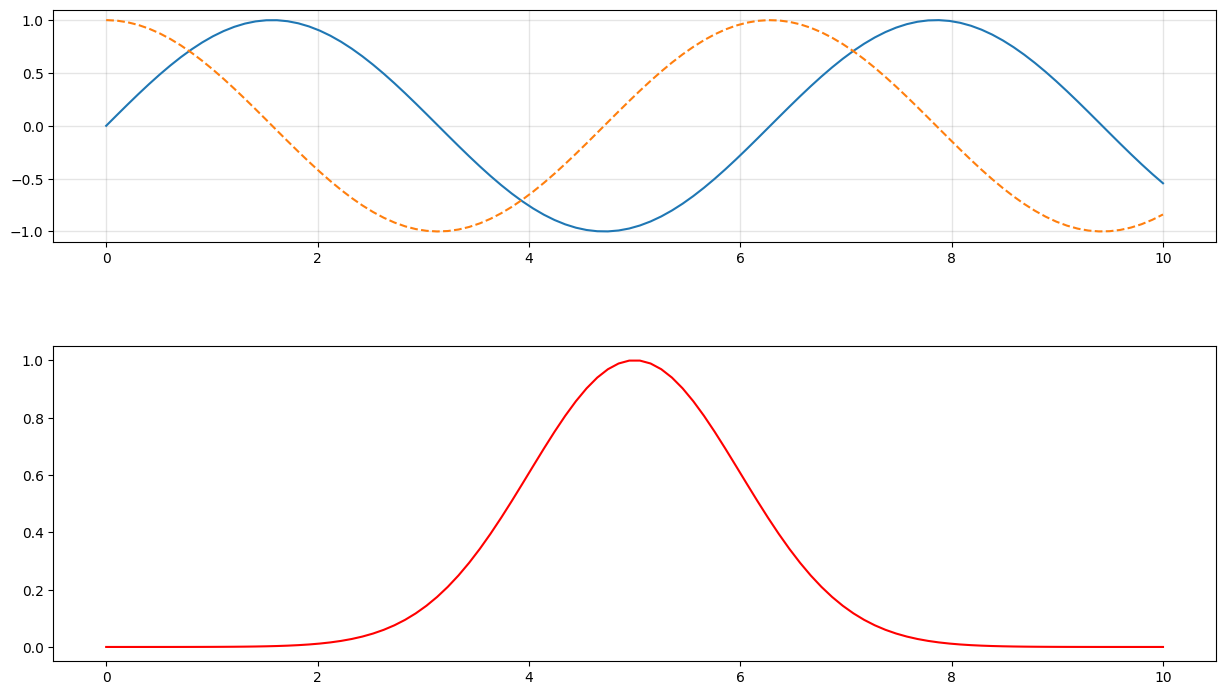

In [21]:
## fig= full graph, ax = indexation sous-graphiques
## nrows = nbr lines de sous graphs
## cols = idem en colonnes

fig, ax = plt.subplots(nrows=2,ncols=1,figsize=(15, 9))

ax[0].plot(x, np.sin(x), '-') # compter àpd 0
ax[0].plot(x, np.cos(x), '--') 

ax[1].plot(x, myfunct(x), c='r')

ax[0].grid(which='both', color='grey', linewidth=1, linestyle='-', alpha=0.2)
ax[0].set( aspect='equal')


### sauvegarder le graphique complet, en pdf (png,...)
fig.savefig('savepdf_1.pdf')
plt.show()

In [22]:
fig.show()

C:\Users\georg\AppData\Local\Temp\ipykernel_29272\89474557.py:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


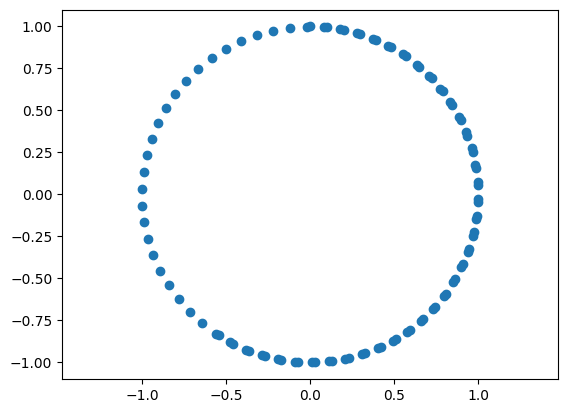

In [23]:
### scatter = nuage de points
plt.scatter(np.sin(x),np.cos(x))
plt.axis('equal')
plt.show()

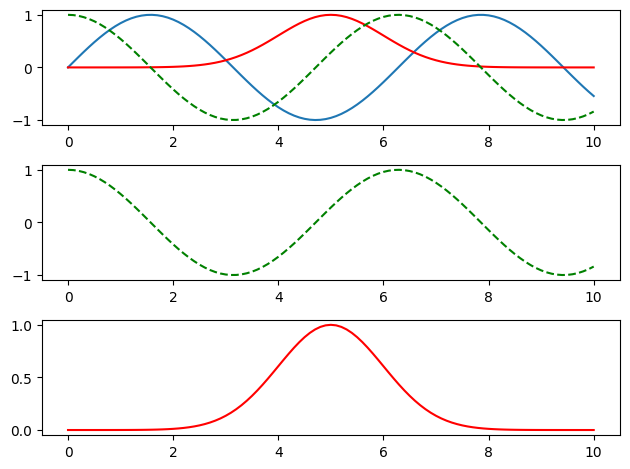

In [45]:
x = np.linspace(0, 10, 101) 

# definir graph contient 3-sub
plt.subplot(3, 1, 1) # (rows, columns, panel number (start @1))
plt.plot(x, np .sin(x))
plt.plot(x, myfunct(x), c='r')
plt.plot(x, np .cos(x), '--', c='green')


plt.subplot(3, 1, 2)
plt.plot(x, np .cos(x), '--', c='green')

plt.subplot(3, 1, 3)
plt.plot(x, myfunct(x), c='r')

### utiliser le tight_layout== ajouter padding pour eviter le chevauchement des graphiques

plt.tight_layout() 

plt.savefig('savepdf_2.pdf')
plt.show()

In [46]:
mean = [0, 0]
cov = [[1, 1], [1, 2]]
x, y = np.random.multivariate_normal(mean, cov, 10000).T

In [48]:
y

array([ 0.05352274, -1.19304646, -0.19183213, ..., -1.4073807 ,
        2.05355304, -2.52268832])

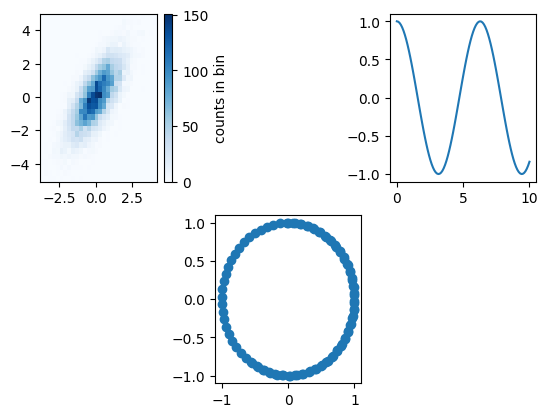

In [25]:
### construction de données artificielles

mean = [0, 0]
cov = [[1, 1], [1, 2]]
x, y = np.random.multivariate_normal(mean, cov, 10000).T


### ------------ ###





plt.subplot(2,3,1) ## compter àpd 1
plt.hist2d(x, y, bins=30, cmap='Blues') # acces à plains de graphiques différents
cb = plt.colorbar()
cb.set_label('counts in bin')

### pas obligé de construire les graphiques dans l'ordre 1,2,3...
z = np.linspace(0,10,100)

plt.subplot(2,3,5)
plt.scatter(np.sin(z),np.cos(z))


plt.subplot(2,3,3)
plt.plot(z, np.cos(z), '-')

plt.show()

[-40 -38 -36 -34 -32 -30 -28 -26 -24 -22 -20 -18 -16 -14 -12 -10  -8  -6
  -4  -2   0   2   4   6   8  10  12  14  16  18  20  22  24  26  28  30
  32  34  36  38  40]


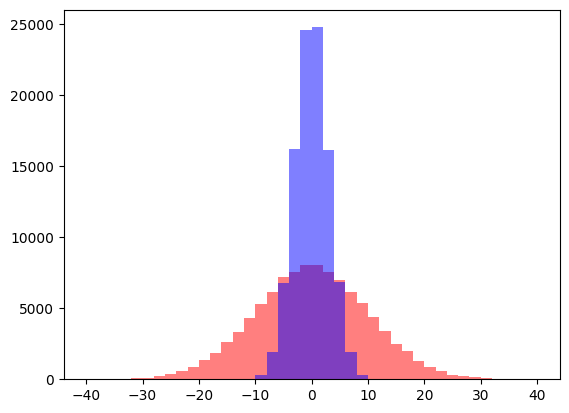

In [26]:
### construction de données
v = np.random.normal(0,3,100_000)
w = np.random.normal(0,10,100_000)

### bins=compartiment pour l'histogramme
bins = np.arange(-40,41,2) # arange(start,stop,step) == list(range(start,stop,step))
### des compartiment : [-40,-38[ ,  [-38, -36[,...
print(bins)

### python: dict avec les params 
pars = {'alpha':0.5,'bins':bins}

plt.hist(w,color='red',**pars, label ="w") # utiliser les params 'pars' du dictionnaire: voir arguments dans fonctions python
plt.hist(v,color='blue',**pars , label = "v")

#plt.hist(w,color='red',alpha=0.5,bins=bins, label ="w") # utiliser les params 'pars' du dictionnaire: voir arguments dans fonctions python
#plt.hist(v,color='blue',alpha=0.5,bins=bins,, label = "v")


plt.show()

In [27]:
pars

{'alpha': 0.5,
 'bins': array([-40, -38, -36, -34, -32, -30, -28, -26, -24, -22, -20, -18, -16,
        -14, -12, -10,  -8,  -6,  -4,  -2,   0,   2,   4,   6,   8,  10,
         12,  14,  16,  18,  20,  22,  24,  26,  28,  30,  32,  34,  36,
         38,  40])}

[-40 -38 -36 -34 -32 -30 -28 -26 -24 -22 -20 -18 -16 -14 -12 -10  -8  -6
  -4  -2   0   2   4   6   8  10  12  14  16  18  20  22  24  26  28  30
  32  34  36  38  40]


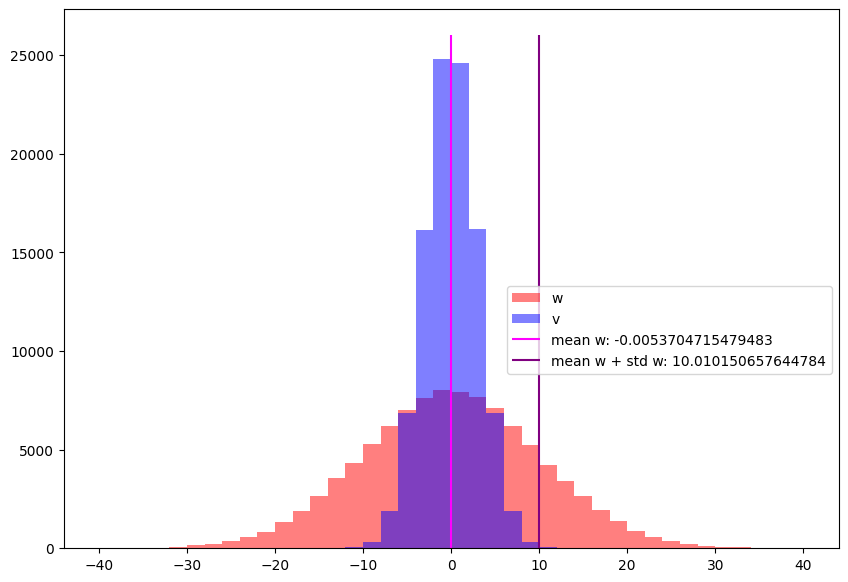

In [28]:
v = np.random.normal(0,3,100_000)
w = np.random.normal(0,10,100_000)

mean_w = np.mean(w)
std_w = np.std(w)


bins = np.arange(-40,41,2)
print(bins)

pars = {'alpha':0.5,'bins':bins}

fig = plt.figure(figsize=(10,7))

plt.hist(w,color='red',**pars, label ="w")
plt.hist(v,color='blue',**pars , label = "v")

### plus avancé : recuperer les min,max du graph existant
ymin, ymax = plt.gca().get_ylim()


### ajouter ligne verticale (horz = hlines)
plt.vlines(mean_w, # x-pos
           ymin=ymin, 
           ymax=ymax,
           color='magenta', 
           label = f'mean w: {mean_w}')

plt.vlines(mean_w+std_w,
           ymin=ymin,
           ymax=ymax,
           color='purple', 
           label = f'mean w + std w: {mean_w + std_w}')

### possibilité de changer l'emplacement de la légende
plt.legend(#loc='center left' # le plus à changer (sans 'bbox_to_achor')
           bbox_to_anchor=(1, 0.5)) #(permet de changer la position plus finement, plus chipoter)
plt.show()

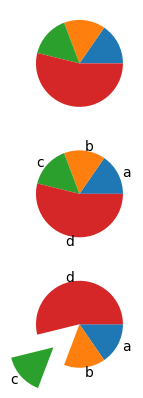

In [ ]:
### creation data

cat = list('abcd')
sze = np.random.randint(2,8,4)
evid = (0,0,0.2,0) 

### pie-plot

# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.pie.html

plt.subplot(3,1,1)
plt.pie(x=sze)

plt.subplot(3,1,2)
plt.pie(x=sze, labels=cat)


plt.subplot(3,1,3)
plt.pie(x=sze
        ,labels=cat
        
        ,explode=evid
        ,counterclock=False
       )
plt.show()

### fake data

In [30]:
N = 10_000

category = np.random.randint(0,5,N)
dict_  = dict(zip(
        range(5)
        ,['red','green','blue', 'purple','cyan']
    ))

color = np.array([dict_[i] for i in category])


def custom_blob(cat_val):   
    return np.random.normal(10*cat_val,1+2*cat_val,1)[0]

def custom_blob2(cat_val):
    return np.random.normal(5*cat_val,1+0.5*cat_val,1)[0]

blob1 = np.array([custom_blob(i) for i in category])
blob2 = np.array([custom_blob2(i) for i in category])

In [31]:
blob1

array([11.37864445, 22.9003162 , 22.93598866, ..., 14.48569361,
       11.09005644, 12.68549139])

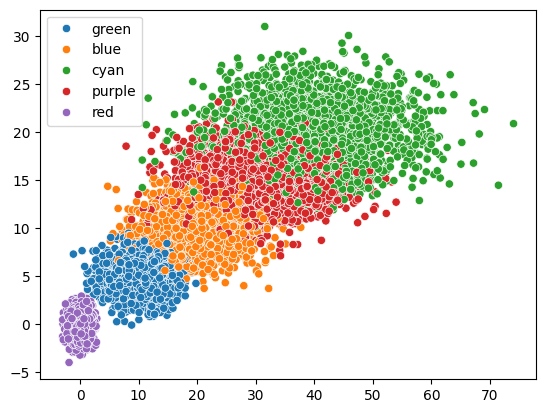

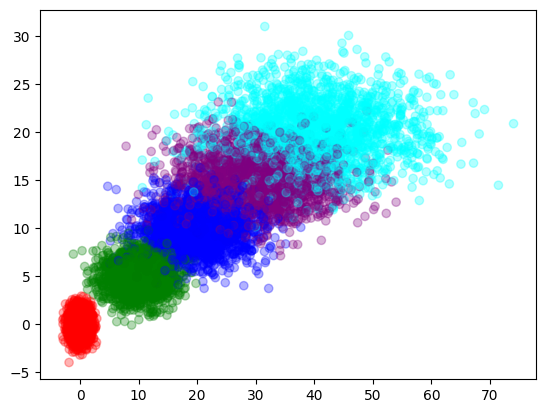

In [32]:
sns.scatterplot(x=blob1,y=blob2,hue=color)
plt.show()
plt.scatter(x=blob1
            ,y=blob2
            ,c=color
            , alpha= 0.3
           )

plt.show()

In [33]:

### indexation booléene sur 'rouge'
is_red = color=="red"
mean_1_red = blob1[is_red].mean()
mean_2_red = blob2[is_red].mean()


is_blue = color=='blue'
mean_1_blue = blob1[is_blue].mean()
mean_2_blue = blob2[is_blue].mean()

### même chose mais systematique

M1 = []
M2 = []
C = np.unique(color)

for c in C:
    M1.append(blob1[color == c].mean())
    M2.append(blob2[color == c].mean())

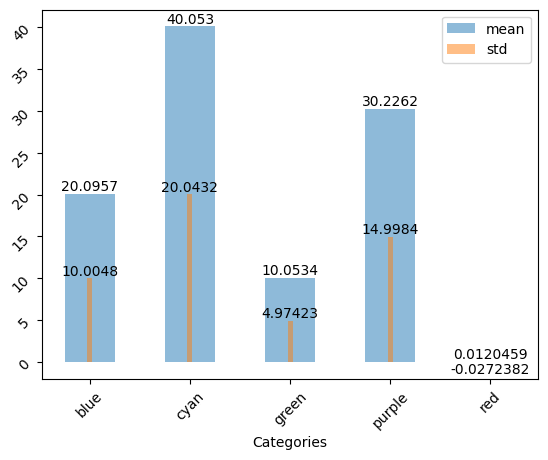

In [34]:
fig,ax = plt.subplots()

plt.bar(x=C , height=M1, alpha=0.5, width = 0.5, label='mean')
plt.bar(x=C , height=M2, alpha=0.5, width= 0.05 , label = 'std')

for bars in ax.containers:
    ax.bar_label(bars) # afficher la valeur d'une barre
plt.yticks(rotation=45)
plt.xticks(rotation=45)
plt.xlabel('Categories')

plt.legend()
plt.show()

# graph: show images


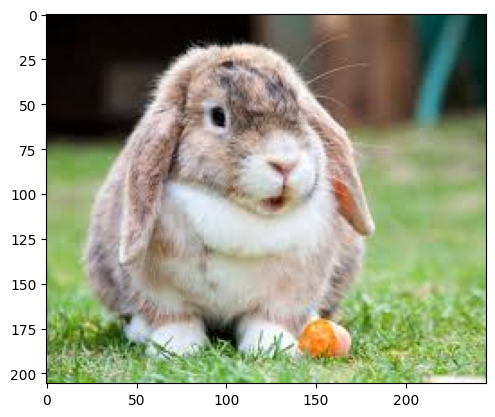

In [51]:
rdm_image = np.random.randint(0,255,(8,8,4)) # (... , ..., 4) : 4=(RED,GREEN,BLUE,ALPHA)

plt.imshow(plt.imread('lapin.jpg'))

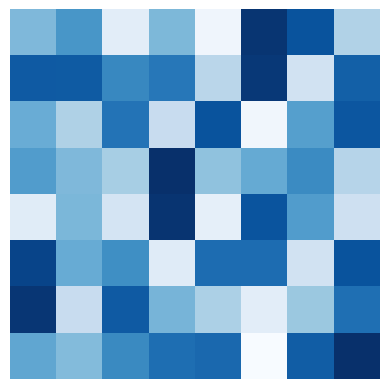

In [36]:
rdm_img2 = np.random.randint(0,255,(8,8)) ## noir et blanc

plt.imshow(rdm_img2, cmap="Blues")
plt.axis("off")
plt.show()

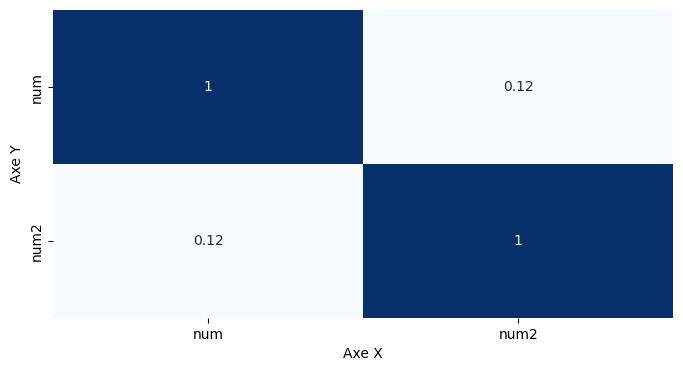

In [53]:
plt.figure(figsize=(8,4))
sns.heatmap(data=df1.corr(numeric_only=True),cbar=False,cmap='Blues',annot=True,fmt=".2g")
plt.xlabel('Axe X')
plt.ylabel('Axe Y')
plt.show()

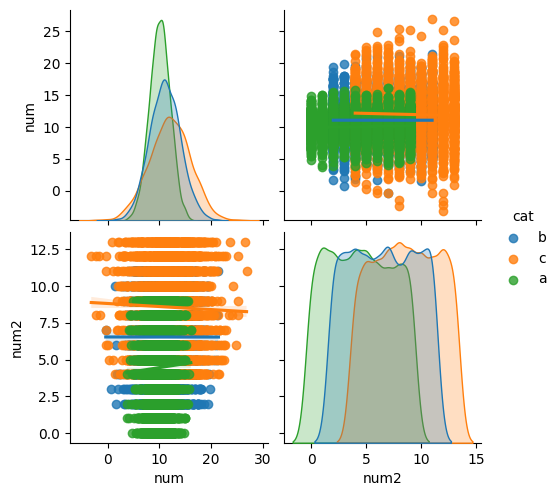

In [38]:
sns.pairplot(data=df1,diag_kind='kde',kind='reg',hue='cat')

<Axes: xlabel='num'>

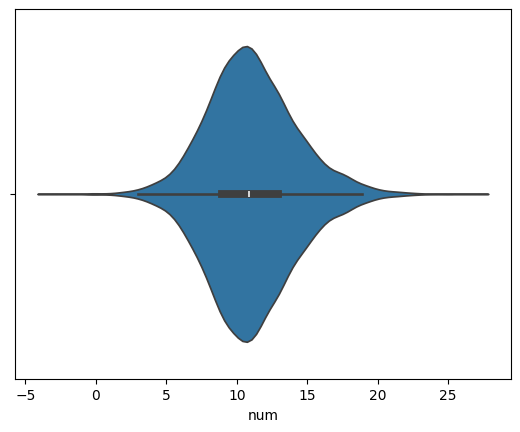

In [39]:
sns.violinplot(data=df1,x='num')

<Axes: xlabel='num'>

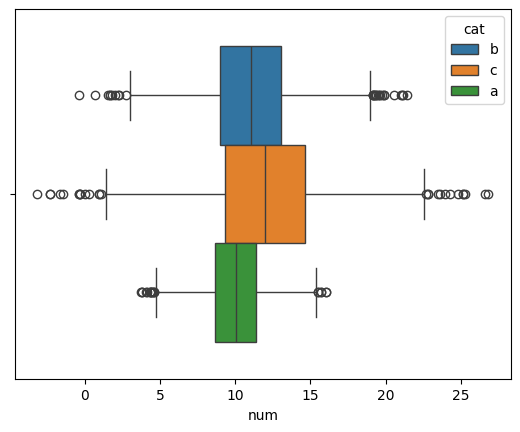

In [ ]:
sns.boxplot(data=df1,x='num',hue='cat')


Moustache basse = Q1 - 1.5 * IQR 
Moustache haute = Q3 + 1.5 * IQR 

<Figure size 200x100 with 0 Axes>

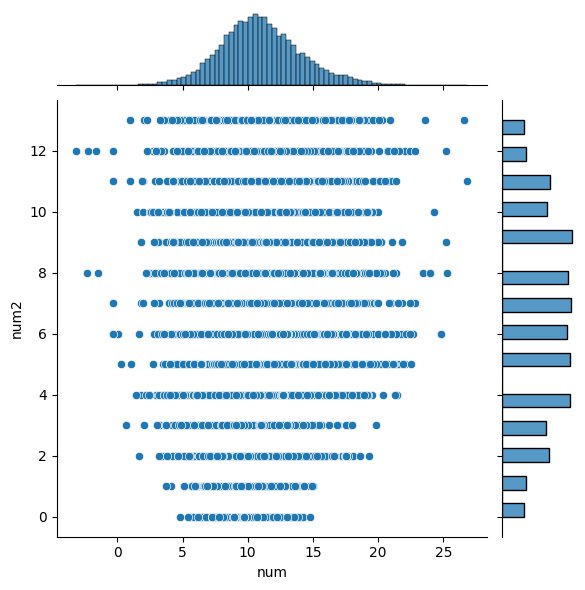

In [41]:
plt.figure(figsize=(2,1))
sns.jointplot(data=df1,x='num',y='num2')
plt.show()